In [2]:
from totalsegmentator.python_api import totalsegmentator
import SimpleITK as sitk, nibabel as nib
import numpy as np, os
from dicom2nifti.common import ConversionValidationError  # to catch that specific error

# ════════════════════════════════════════════════════════════════════════════════
# 📁 PARENT FOLDER CONTAINING MULTIPLE DICOM SUBFOLDERS
# ════════════════════════════════════════════════════════════════════════════════

parent_dir = r"D:\Abdomen_CT_Bone_Mets"
pelvis_labels = ["hip_left", "hip_right"]
lung_labels   = [
    "lung_upper_lobe_left",
    "lung_lower_lobe_left",
    "lung_upper_lobe_right",
    "lung_middle_lobe_right",
    "lung_lower_lobe_right"
]

# Sort subfolders by their trailing numeric part (e.g., BMAB1_00000001 → 1, BMAB1_00000002 → 2, etc.)
def sort_key(name):
    try:
        # If the last underscore‐separated piece is an integer, use that
        num = int(name.split("_")[-1])
        return (0, num)
    except ValueError:
        # Otherwise, put it after all numeric names and sort alphabetically
        return (1, name)

for subfolder in sorted(os.listdir(parent_dir), key=sort_key):
    dicom_dir = os.path.join(parent_dir, subfolder)
    if not os.path.isdir(dicom_dir):
        continue

    print(f"\n🔄 Processing folder: {dicom_dir}")

    # ─────────── Output folders and combined‐mask paths ───────────
    pelvis_out_dir = os.path.join(dicom_dir, "_seg_pelvis")
    lung_out_dir   = os.path.join(dicom_dir, "_seg_lung")

    pelvis_combined_f = os.path.join(pelvis_out_dir, "hips_combined.nii.gz")
    lung_combined_f   = os.path.join(lung_out_dir,   "lungs_combined.nii.gz")

    # If both combined outputs already exist, skip entire folder
    if os.path.exists(pelvis_combined_f) and os.path.exists(lung_combined_f):
        print(f"ℹ️  Skipping {subfolder}: combined outputs already exist.")
        continue

    # ─────── Helper: attempt segmentation on DICOM, else fallback to a SITK‐converted NIfTI ───────
    def run_totalseg_on(input_path, out_dir, labels):
        """
        Try totalsegmentator(input_path), and if a ConversionValidationError is raised,
        convert `input_path` (a DICOM folder) to a temporary NIfTI via SimpleITK, then re‐run totalseg.
        Returns nothing, but ensures that `out_dir/<label>.nii.gz` exists for each label.
        """
        try:
            totalsegmentator(
                input_path, out_dir,
                roi_subset=labels,
                fast=True,
                nr_thr_resamp=1, nr_thr_saving=1,
                device="gpu"
            )
        except ConversionValidationError:
            # 1) Convert DICOM folder → NIfTI using SITK
            print(f"⚠️  DICOM→NIfTI failed validation for {input_path}. Falling back to SimpleITK conversion.")
            reader = sitk.ImageSeriesReader()
            reader.SetFileNames(reader.GetGDCMSeriesFileNames(input_path))
            ct_itk = reader.Execute()
            # Write out a temporary NIfTI in the same folder
            nifti_tmp = os.path.join(input_path, "ct_converted.nii.gz")
            sitk.WriteImage(ct_itk, nifti_tmp)
            # 2) Run totalsegmentator on that NIfTI file
            totalsegmentator(
                nifti_tmp, out_dir,
                roi_subset=labels,
                fast=True,
                nr_thr_resamp=1, nr_thr_saving=1,
                device="gpu"
            )
            # Optionally remove the temporary NIfTI:
            os.remove(nifti_tmp)

    # ────────────── BLOCK 1A: Pelvis segmentation + combine hips ──────────────
    if not os.path.exists(pelvis_combined_f):
        os.makedirs(pelvis_out_dir, exist_ok=True)
        run_totalseg_on(dicom_dir, pelvis_out_dir, pelvis_labels)

        mask_combined = None
        for lab in pelvis_labels:
            fpath = os.path.join(pelvis_out_dir, f"{lab}.nii.gz")
            img   = nib.load(fpath)
            data  = img.get_fdata().astype(bool)

            if mask_combined is None:
                mask_combined = data
                affine, header = img.affine, img.header
            else:
                mask_combined |= data

        nib.save(nib.Nifti1Image(mask_combined.astype(np.uint8), affine, header), pelvis_combined_f)
        print("✅ Pelvis combined NIfTI saved ➜", pelvis_combined_f)
    else:
        print(f"ℹ️  {subfolder}: hips_combined.nii.gz already exists, skipping pelvis block.")

    # ────────────── BLOCK 1B: Lung segmentation + combine lobes ──────────────
    if not os.path.exists(lung_combined_f):
        os.makedirs(lung_out_dir, exist_ok=True)
        run_totalseg_on(dicom_dir, lung_out_dir, lung_labels)

        mask_combined = None
        for lab in lung_labels:
            fpath = os.path.join(lung_out_dir, f"{lab}.nii.gz")
            img   = nib.load(fpath)
            data  = img.get_fdata().astype(bool)

            if mask_combined is None:
                mask_combined = data
                affine, header = img.affine, img.header
            else:
                mask_combined |= data

        nib.save(nib.Nifti1Image(mask_combined.astype(np.uint8), affine, header), lung_combined_f)
        print("✅ Lung mask combined ➜", lung_combined_f)
    else:
        print(f"ℹ️  {subfolder}: lungs_combined.nii.gz already exists, skipping lung block.")


🔄 Processing folder: D:\Abdomen_CT_Bone_Mets\BMAB1_00000001
ℹ️  Skipping BMAB1_00000001: combined outputs already exist.

🔄 Processing folder: D:\Abdomen_CT_Bone_Mets\BMAB2_00000001
ℹ️  Skipping BMAB2_00000001: combined outputs already exist.

🔄 Processing folder: D:\Abdomen_CT_Bone_Mets\BMAB3_00000001
ℹ️  Skipping BMAB3_00000001: combined outputs already exist.

🔄 Processing folder: D:\Abdomen_CT_Bone_Mets\BMAB1_00000002
ℹ️  Skipping BMAB1_00000002: combined outputs already exist.

🔄 Processing folder: D:\Abdomen_CT_Bone_Mets\BMAB2_00000002
ℹ️  Skipping BMAB2_00000002: combined outputs already exist.

🔄 Processing folder: D:\Abdomen_CT_Bone_Mets\BMAB3_00000002
ℹ️  Skipping BMAB3_00000002: combined outputs already exist.

🔄 Processing folder: D:\Abdomen_CT_Bone_Mets\BMAB1_00000003
ℹ️  Skipping BMAB1_00000003: combined outputs already exist.

🔄 Processing folder: D:\Abdomen_CT_Bone_Mets\BMAB2_00000003
ℹ️  Skipping BMAB2_00000003: combined outputs already exist.

🔄 Processing folder: D:

100%|██████████| 8/8 [00:00<00:00, 27.64it/s]


  Predicted in 7.00s
Resampling...
Converting dicom to nifti...
  found image with shape (804, 804, 837)
  cropping from (804, 804, 837) to (689, 408, 504)
Resampling...
  Resampled in 3.43s
Predicting...


100%|██████████| 1/1 [00:00<00:00,  2.20it/s]


  Predicted in 7.02s
Resampling...
Saving segmentations...
Shape of output image is very big. Setting nr_threads_saving=1 to save memory.
  Saved in 10.04s
✅ Pelvis combined NIfTI saved ➜ D:\Abdomen_CT_Bone_Mets\BMAB2_00000016\_seg_pelvis\hips_combined.nii.gz

If you use this tool please cite: https://pubs.rsna.org/doi/10.1148/ryai.230024

Using 'fast' option: resampling to lower resolution (3mm)
Generating rough segmentation for cropping...
Converting dicom to nifti...
  found image with shape (804, 804, 837)
Resampling...
  Resampled in 11.47s
Predicting...


...

100%|██████████| 8/8 [00:00<00:00, 58.34it/s]


  Predicted in 6.38s
Resampling...
Converting dicom to nifti...
  found image with shape (512, 512, 1088)
  cropping from (512, 512, 1088) to (374, 240, 527)
Resampling...
  Resampled in 1.02s
Predicting...


100%|██████████| 1/1 [00:00<00:00, 124.57it/s]


  Predicted in 6.59s
Resampling...
Saving segmentations...
Shape of output image is very big. Setting nr_threads_saving=1 to save memory.
  Saved in 5.44s
✅ Pelvis combined NIfTI saved ➜ D:\Abdomen_CT_Bone_Mets\BMAB1_00000023\_seg_pelvis\hips_combined.nii.gz

If you use this tool please cite: https://pubs.rsna.org/doi/10.1148/ryai.230024

Using 'fast' option: resampling to lower resolution (3mm)
Generating rough segmentation for cropping...
Converting dicom to nifti...


NotADirectoryError: [WinError 267] The directory name is invalid: 'C:\\Users\\RYANKR~1\\AppData\\Local\\Temp\\nnunet_tmp_a2dg3l3j\\dcm\\converted_dcm.nii.gz'

In [4]:
import os
import numpy as np
import pandas as pd
import SimpleITK as sitk

# ────────────────────────────────────────────────────────────────────────────────
# Helper: align a NIfTI mask to ct_ras’s voxel grid (copied from your first script)
# ────────────────────────────────────────────────────────────────────────────────
def align_mask_to_ct(mask_path, ct_ras):
    mask_itk = sitk.ReadImage(mask_path)
    orig_np  = sitk.GetArrayFromImage(mask_itk).astype(bool)
    if not orig_np.any():
        raise RuntimeError(f"Mask {mask_path!r} is empty → cannot align.")

    size_matches   = (mask_itk.GetSize() == ct_ras.GetSize())
    spacing_ct     = np.array(ct_ras.GetSpacing(), dtype=float)
    spacing_mk     = np.array(mask_itk.GetSpacing(), dtype=float)
    spacing_matches = np.allclose(spacing_ct, spacing_mk, atol=1e-6)

    # If size and spacing already match, just flip axes and copy metadata:
    if size_matches and spacing_matches:
        flipped = orig_np[::-1, :, ::-1]
        fixed_itk = sitk.GetImageFromArray(flipped.astype(np.uint8))
        fixed_itk.CopyInformation(ct_ras)
        aligned_np = sitk.GetArrayFromImage(fixed_itk).astype(bool)
        if not aligned_np.any():
            raise RuntimeError(f"After flip+copy, {mask_path!r} is still empty.")
        return aligned_np

    # Otherwise, reorient → resample onto CT grid
    orienter = sitk.DICOMOrientImageFilter()
    orienter.SetDesiredCoordinateOrientation("RAS")
    mask_ras = orienter.Execute(mask_itk)

    mask_resampled = sitk.Resample(
        mask_ras,                  # input
        ct_ras,                    # reference grid (handles size, spacing, origin)
        sitk.Transform(),          # identity transform
        sitk.sitkNearestNeighbor,  # nearest neighbor to keep it binary
        0.0,
        mask_ras.GetPixelID()
    )
    aligned_np = sitk.GetArrayFromImage(mask_resampled).astype(bool)
    if not aligned_np.any():
        raise RuntimeError(f"After orient+resample, {mask_path!r} has no overlap with CT.")
    return aligned_np


# ────────────────────────────────────────────────────────────────────────────────
# Adjust this “root_dir” to point at your top‐level folder (e.g. D:\Abdomen_CT_Bone_Mets)
# ────────────────────────────────────────────────────────────────────────────────
root_dir = r"D:\Abdomen_CT_Bone_Mets"

# ────────────────────────────────────────────────────────────────────────────────
# Constants
#   – allowance_mm is still 30 mm in both directions
#   – mask filenames are assumed to be exactly:
#       lungs_combined.nii (or .nii.gz)
#       hips_combined.nii   (or .nii.gz)
# ────────────────────────────────────────────────────────────────────────────────
allowance_mm     = 30.0
lung_mask_name   = "lungs_combined"
pelvis_mask_name = "hips_combined"

# ────────────────────────────────────────────────────────────────────────────────
# Helper: find a file named “base_name.nii” or “base_name.nii.gz” under a given directory
# ────────────────────────────────────────────────────────────────────────────────
def find_mask_file(folder, base_name):
    candidates = [f"{base_name}.nii", f"{base_name}.nii.gz"]
    for fn in candidates:
        path = os.path.join(folder, fn)
        if os.path.isfile(path):
            return path
    return None


# ────────────────────────────────────────────────────────────────────────────────
# Prepare a list to collect results (will convert into a DataFrame at the end)
# ────────────────────────────────────────────────────────────────────────────────
results = []

# ────────────────────────────────────────────────────────────────────────────────
# Loop through each “patient” subfolder in root_dir
# ────────────────────────────────────────────────────────────────────────────────
for patient_id in os.listdir(root_dir):
    patient_dir = os.path.join(root_dir, patient_id)
    if not os.path.isdir(patient_dir):
        continue

    # Expecting two subfolders inside each patient folder:
    #   _seg_lung      (contains lungs_combined.nii or .nii.gz)
    #   _seg_pelvis    (contains hips_combined.nii or .nii.gz)
    lung_seg_dir   = os.path.join(patient_dir, "_seg_lung")
    pelvis_seg_dir = os.path.join(patient_dir, "_seg_pelvis")

    if not (os.path.isdir(lung_seg_dir) and os.path.isdir(pelvis_seg_dir)):
        print(f"→ Skipping {patient_id}: missing _seg_lung or _seg_pelvis folder")
        continue

    lung_mask_f   = find_mask_file(lung_seg_dir,   lung_mask_name)
    pelvis_mask_f = find_mask_file(pelvis_seg_dir, pelvis_mask_name)

    if lung_mask_f is None or pelvis_mask_f is None:
        print(f"→ Skipping {patient_id}: could not find mask files in subfolders")
        continue

    # We assume the DICOM series for CT is directly under patient_dir:
    dicom_dir = patient_dir

    print("\n" + "─" * 80)
    print(f"📂 Processing patient: {patient_id}")

    try:
        # ────────────────────────────────────────────────────────────────────────────
        # Load CT series and reorient to RAS
        # ────────────────────────────────────────────────────────────────────────────
        reader = sitk.ImageSeriesReader()
        reader.SetFileNames(reader.GetGDCMSeriesFileNames(dicom_dir))
        ct_itk = reader.Execute()

        orienter = sitk.DICOMOrientImageFilter()
        orienter.SetDesiredCoordinateOrientation("RAS")
        ct_ras = orienter.Execute(ct_itk)

        # Grab CT spacing and size (so we know how many slices and mm/slice)
        spacing_ct_z = ct_ras.GetSpacing()[2]      # slice thickness (mm)
        z_dim_ct     = ct_ras.GetSize()[2]         # number of slices

        # ────────────────────────────────────────────────────────────────────────────
        # Diaphragm Detection (Cranial Overscan) via “Full‐Lung” logic
        # ────────────────────────────────────────────────────────────────────────────
        # Align the lung mask to CT grid (boolean ndarray of shape (Z, Y, X))
        mask_np_lung = align_mask_to_ct(lung_mask_f, ct_ras)

        # Find the slice‐index in mask‐space that has the maximum lung area
        lung_counts_per_slice = mask_np_lung.sum(axis=(1, 2))
        if not lung_counts_per_slice.any():
            raise RuntimeError("Lung mask has no voxels → cannot find diaphragm.")

        mask_z_diaphragm = int(np.argmax(lung_counts_per_slice))
        diaphragm_ct_z   = mask_z_diaphragm  # because mask is already on CT grid

        # Compute distance above diaphragm in mm: (top_slice_index – diaphragm_index) * thickness
        top_ct_slice         = z_dim_ct - 1
        distance_above_mm    = (top_ct_slice - diaphragm_ct_z) * spacing_ct_z
        overscan_mm_cranial  = max(0.0, distance_above_mm - allowance_mm)

        print(f"🫁 Diaphragm (mask‐slice)           = {mask_z_diaphragm}")
        print(f"🫁 Diaphragm (CT‐slice)            = {diaphragm_ct_z}")
        print(f"📏 Distance above diaphragm        = {distance_above_mm:.1f} mm")
        if overscan_mm_cranial <= 0:
            print("✅ No cranial overscan (within 30 mm allowance).")
        else:
            slices_over = overscan_mm_cranial / spacing_ct_z
            print(
                f"⚠️  Cranial overscan               = {overscan_mm_cranial:.1f} mm "
                f"(≈ {slices_over:.1f} slices)"
            )

        # ────────────────────────────────────────────────────────────────────────────
        # Pubic Symphysis Detection (Caudal Overscan)
        # ────────────────────────────────────────────────────────────────────────────
        # Align the pelvis mask to CT grid
        mask_np_pelvis = align_mask_to_ct(pelvis_mask_f, ct_ras)

        # Find mid‐sagittal x‐index: simply use the middle X in CT grid
        # (mask_np_pelvis shape is (Z, Y, X) already aligned to CT).
        x_dim_ct = mask_np_pelvis.shape[2]
        mid_x    = x_dim_ct // 2
        x_start  = max(0, mid_x - 2)
        x_end    = min(x_dim_ct, mid_x + 3)

        # For each slice, check if any voxel appears in that 5‐voxel midline band
        z_dim_p = mask_np_pelvis.shape[0]
        z_midline_hits = [
            z for z in range(z_dim_p)
            if mask_np_pelvis[z, :, x_start:x_end].any()
        ]
        if len(z_midline_hits) == 0:
            raise RuntimeError("No midline contact → symphysis not detected.")

        # The *lowest*‐index in mask‐space with a midline hit is pubic symphysis
        mask_z_pubis = int(min(z_midline_hits))
        pubic_ct_z   = mask_z_pubis  # again, mask‐space == CT‐space here

        # Distance from CT bottom to pubic symphysis = pubic_ct_z * slice_thickness
        distance_below_mm   = pubic_ct_z * spacing_ct_z
        overscan_mm_caudal  = max(0.0, distance_below_mm - allowance_mm)

        print(f"\n🦴 Symphysis (mask‐slice)           = {mask_z_pubis}")
        print(f"🦴 Symphysis (CT‐slice)            = {pubic_ct_z}")
        print(f"📏 Distance below symphysis        = {distance_below_mm:.1f} mm")
        if overscan_mm_caudal <= 0:
            print("✅ No caudal overscan (within 30 mm allowance).")
        else:
            slices_over_c = overscan_mm_caudal / spacing_ct_z
            print(
                f"⚠️  Caudal overscan                = {overscan_mm_caudal:.1f} mm "
                f"(≈ {slices_over_c:.1f} slices)"
            )

        # ────────────────────────────────────────────────────────────────────────────
        # Append results into the list
        # ────────────────────────────────────────────────────────────────────────────
        row = {
            "patient_id":           patient_id,
            "diaphragm_idx":        diaphragm_ct_z,
            "distance_above_mm":    distance_above_mm,
            "overscan_mm_cranial":  overscan_mm_cranial,
            "pubic_idx":            pubic_ct_z,
            "distance_below_mm":    distance_below_mm,
            "overscan_mm_caudal":   overscan_mm_caudal
        }
        results.append(row)

    except Exception as e:
        print(f"‼️  Error processing {patient_id}: {e}")
        # You can choose to append NaNs here or just skip.


# ────────────────────────────────────────────────────────────────────────────────
# After all patients are processed: build DataFrame, print summary, save to CSV
# ────────────────────────────────────────────────────────────────────────────────
df = pd.DataFrame(results, columns=[
    "patient_id",
    "diaphragm_idx",
    "distance_above_mm",
    "overscan_mm_cranial",
    "pubic_idx",
    "distance_below_mm",
    "overscan_mm_caudal"
])

print("\n=== DataFrame Head ===")
print(df.head())

print("\n=== DataFrame Summary (describe) ===")
print(df.describe())

output_csv = os.path.join(root_dir, "overscan_results.csv")
df.to_csv(output_csv, index=False)
print(f"\n✅ Results saved to: {output_csv}")

→ Skipping BMAB3_00000240: missing _seg_lung or _seg_pelvis folder
→ Skipping BMAB3_00000241: missing _seg_lung or _seg_pelvis folder
→ Skipping BMAB3_00000242: missing _seg_lung or _seg_pelvis folder
→ Skipping BMAB3_00000243: missing _seg_lung or _seg_pelvis folder
→ Skipping BMAB3_00000244: missing _seg_lung or _seg_pelvis folder
→ Skipping BMAB3_00000245: missing _seg_lung or _seg_pelvis folder
→ Skipping BMAB3_00000246: missing _seg_lung or _seg_pelvis folder
→ Skipping BMAB3_00000247: missing _seg_lung or _seg_pelvis folder
→ Skipping BMAB3_00000248: missing _seg_lung or _seg_pelvis folder
→ Skipping BMAB3_00000249: missing _seg_lung or _seg_pelvis folder
→ Skipping BMAB3_00000250: missing _seg_lung or _seg_pelvis folder

────────────────────────────────────────────────────────────────────────────────
📂 Processing patient: BMAB1_00000001
🫁 Diaphragm (mask‐slice)           = 10
🫁 Diaphragm (CT‐slice)            = 10
📏 Distance above diaphragm        = 452.0 mm
⚠️  Cranial overscan

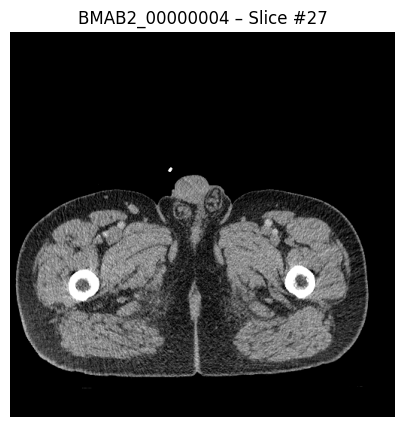

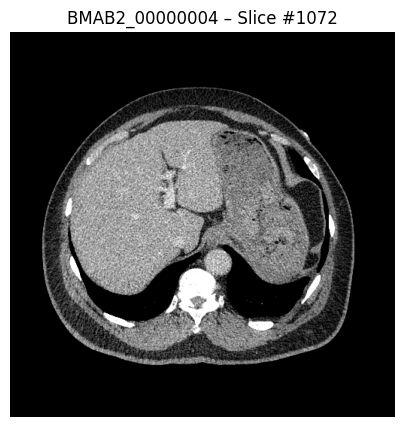

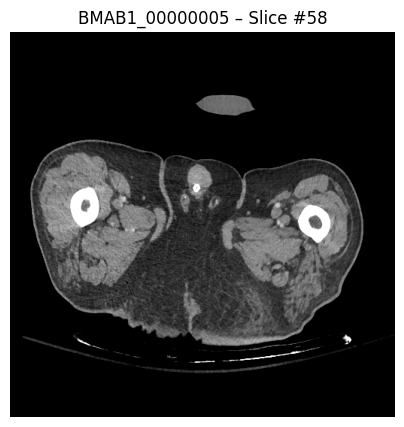

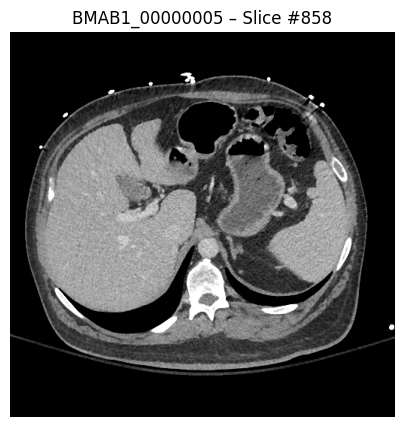

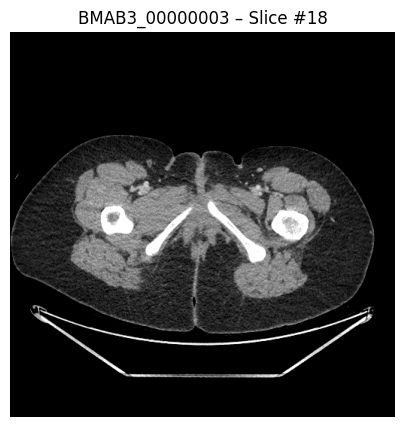

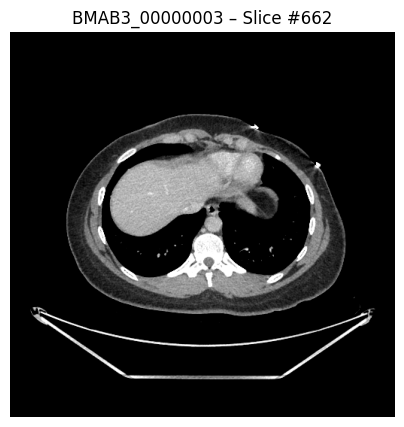

In [13]:
# %% [markdown]
# ## Display specific CT slices for each patient in D:\Abdomen_CT_Bone_Mets
# 
# This code:
# 1. Iterates over three patient‐IDs.
# 2. For each, reads the DICOM series from the corresponding subfolder.
# 3. Extracts the two slice‐indices you requested.
# 4. Applies a simple HU window (center=40, width=400) and shows them inline.

# %% [code]
import os
import numpy as np
import SimpleITK as sitk
import matplotlib.pyplot as plt

# If running in Jupyter, ensure inline plotting
# (In VS Code Jupyter it’s usually on by default; uncomment if needed)
# %matplotlib inline

# Base folder where each patient’s DICOM-series folder lives
base_path = r"D:\Abdomen_CT_Bone_Mets"

# Dictionary: patient_ID → [diaphragm_slice_index, symphysis_slice_index]
patients = {
    "BMAB2_00000004": [27, 1072],
    "BMAB1_00000005": [58, 858],
    "BMAB3_00000003": [18, 662],
}

def window_image(img_array: np.ndarray, center: float = 40, width: float = 400) -> np.ndarray:
    """
    Apply a HU window to a NumPy array slice.
    - center: window center (e.g. 40 HU)
    - width: window width (e.g. 400 HU)
    Returns a float32 array scaled 0.0–1.0 for display.
    """
    lower = center - (width / 2)
    upper = center + (width / 2)
    # Clip to the window and scale to [0,1]
    img_clipped = np.clip(img_array, lower, upper)
    img_normalized = (img_clipped - lower) / (upper - lower)
    return img_normalized.astype(np.float32)

for patient_id, slice_idxs in patients.items():
    folder_path = os.path.join(base_path, patient_id)
    if not os.path.isdir(folder_path):
        raise FileNotFoundError(f"Folder not found: {folder_path}")
    
    # Read the DICOM series from the folder
    reader = sitk.ImageSeriesReader()
    series_IDs = reader.GetGDCMSeriesIDs(folder_path)
    if not series_IDs:
        raise RuntimeError(f"No DICOM series found under {folder_path}")
    
    # Use the first series (most folders have exactly one series per patient folder)
    series_file_names = reader.GetGDCMSeriesFileNames(folder_path, series_IDs[0])
    reader.SetFileNames(series_file_names)
    image_3d = reader.Execute()
    
    # Convert to NumPy (SimpleITK returns array with shape [Z, Y, X])
    volume_np = sitk.GetArrayFromImage(image_3d)
    
    # Loop over the two slice indices for this patient
    for idx in slice_idxs:
        if idx < 0 or idx >= volume_np.shape[0]:
            raise IndexError(f"Slice index {idx} out of bounds for {patient_id} (max index = {volume_np.shape[0]-1})")
        
        slice_np = volume_np[idx, :, :]
        slice_win = window_image(slice_np, center=40, width=400)
        
        plt.figure(figsize=(5, 5))
        plt.imshow(slice_win, cmap="gray", vmin=0.0, vmax=1.0)
        plt.title(f"{patient_id} – Slice #{idx}")
        plt.axis("off")
        plt.show()

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Ensure inline plotting
%matplotlib inline

# Load the CSV from /mnt/data
csv_path = "D:\Abdomen_CT_Bone_Mets\overscan_results.csv"
df = pd.read_csv(csv_path)

# Create boolean columns for cranial and caudal overscan
df['cranial_overscan'] = df['overscan_mm_cranial'] > 0
df['caudal_overscan'] = df['overscan_mm_caudal'] > 0

# Calculate counts and averages for cranial overscan
total_scans = len(df)
cranial_count = df['cranial_overscan'].sum()
cranial_no_count = total_scans - cranial_count
avg_cranial_overscan = df.loc[df['cranial_overscan'], 'overscan_mm_cranial'].mean()

# Calculate counts and averages for caudal overscan
caudal_count = df['caudal_overscan'].sum()
caudal_no_count = total_scans - caudal_count
avg_caudal_overscan = df.loc[df['caudal_overscan'], 'overscan_mm_caudal'].mean()

# Print summary statistics
print("=== Cranial Overscan (Lungs) ===")
print(f"Total scans: {total_scans}")
print(f"Scans with cranial overscan: {cranial_count}")
print(f"Scans without cranial overscan: {cranial_no_count}")
print(f"Average cranial overscan (among overscanned): {avg_cranial_overscan:.2f} mm\n")

print("=== Caudal Overscan (Pubic) ===")
print(f"Total scans: {total_scans}")
print(f"Scans with caudal overscan: {caudal_count}")
print(f"Scans without caudal overscan: {caudal_no_count}")
print(f"Average caudal overscan (among overscanned): {avg_caudal_overscan:.2f} mm\n")

# Plot 1: Bar chart of counts
counts_df = pd.DataFrame({
    'Type': ['Cranial (Lungs)', 'Cranial (Lungs)',
             'Caudal (Pubic)', 'Caudal (Pubic)'],
    'Overscan': ['Yes', 'No', 'Yes', 'No'],
    'Count': [cranial_count, cranial_no_count, caudal_count, caudal_no_count]
})

plt.figure(figsize=(8, 5))
sns.barplot(data=counts_df, x='Type', y='Count', hue='Overscan', palette={'Yes':'tab:blue', 'No':'tab:gray'})
plt.title('Count of Scans with/without Overscan (Cranial vs Caudal)')
plt.ylabel('Number of Scans')
plt.xlabel('Overscan Type')
plt.legend(title='Overscan')
plt.tight_layout()
plt.show()

# Plot 2: Distribution of overscan amounts
plt.figure(figsize=(8, 5))
sns.histplot(data=df[df['cranial_overscan']], x='overscan_mm_cranial', bins=10, kde=True, color='steelblue', label='Cranial > 0')
sns.histplot(data=df[df['caudal_overscan']], x='overscan_mm_caudal', bins=10, kde=True, color='salmon', label='Caudal > 0')
plt.title('Distribution of Overscan Amounts (mm) (Cranial vs Caudal)')
plt.xlabel('Overscan Amount (mm)')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()